# Notebook status and evaluation note

This notebook is retained as a portfolio record of the original experiment. The workflow evaluates `test_loader` during training and uses test accuracy for checkpoint selection. Its stored metrics are therefore **historical development results**, not a final estimate from an untouched test set. A rigorous rerun should select checkpoints on a separate validation split and evaluate the test split once.

The original Google Colab and Google Drive paths are also retained and must be changed before running the notebook.


In [ ]:
# 0. Install required libraries
# =======================================================================
!pip install -q numpy pandas scikit-learn matplotlib seaborn torch torchvision qiskit qiskit-machine-learning qiskit-aer imbalanced-learn tqdm

# ==========

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00


In [ ]:
# 1. Imports & Setup (QISKIT-SAFE)
# =======================================================================
import os, random, math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------- QISKIT (V2 ONLY - VERY IMPORTANT) --------
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.quantum_info import SparsePauliOp

# -------- Metrics --------
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import shutil

In [ ]:
# 2. Reproducibility
# =======================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [ ]:
# 3. Mount Google Drive & Load Dataset
# =======================================================================
from google.colab import drive
import zipfile

drive.mount('/content/drive')
zip_path = "/content/drive/MyDrive/chest_xray.zip"
extract_path = "/content/MyDrive/chest_xray"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
print("Dataset ready at:", extract_path)


Mounted at /content/drive
Dataset ready at: /content/MyDrive/chest_xray


In [ ]:
# 4. Merge train+test+val -> Balance -> 80-20 Split (ROBUST)
# =======================================================================
set_seed(42)

base = extract_path
if os.path.isdir(os.path.join(base, "chest_xray")):
    base = os.path.join(base, "chest_xray")

print("Using base dataset path:", base)

def find_class_dir(parent, class_name):
    for d in os.listdir(parent):
        if d.lower() == class_name.lower():
            return os.path.join(parent, d)
    raise FileNotFoundError(f"{class_name} not found in {parent}")

normal_dirs = []
pneumonia_dirs = []

for split in ["train", "test", "val"]:
    split_path = os.path.join(base, split)
    try:
        normal_dirs.append(find_class_dir(split_path, "normal"))
        pneumonia_dirs.append(find_class_dir(split_path, "pneumonia"))
    except FileNotFoundError:
        pass

# Collect image paths
normal_imgs = []
for d in normal_dirs:
    normal_imgs += [os.path.join(d, f) for f in os.listdir(d)]

pneumonia_imgs = []
for d in pneumonia_dirs:
    pneumonia_imgs += [os.path.join(d, f) for f in os.listdir(d)]

print("Original counts -> Normal:", len(normal_imgs), "Pneumonia:", len(pneumonia_imgs))

# -------- BALANCING --------
pneumonia_imgs = random.sample(pneumonia_imgs, len(normal_imgs))

# -------- SPLIT --------
norm_train, norm_test = train_test_split(normal_imgs, test_size=0.2, random_state=42)
pneu_train, pneu_test = train_test_split(pneumonia_imgs, test_size=0.2, random_state=42)

# Output folders
balanced_base = "/content/balanced_chest_xray"
train_dir = f"{balanced_base}/train"
test_dir = f"{balanced_base}/test"

for cls in ["NORMAL", "PNEUMONIA"]:
    os.makedirs(f"{train_dir}/{cls}", exist_ok=True)
    os.makedirs(f"{test_dir}/{cls}", exist_ok=True)

def copy_files(files, dst):
    for f in files:
        shutil.copy(f, dst)

copy_files(norm_train, f"{train_dir}/NORMAL")
copy_files(norm_test, f"{test_dir}/NORMAL")
copy_files(pneu_train, f"{train_dir}/PNEUMONIA")
copy_files(pneu_test, f"{test_dir}/PNEUMONIA")

print("Balanced dataset created")
print("Train -> Normal:", len(norm_train), "Pneumonia:", len(pneu_train))
print("Test  -> Normal:", len(norm_test), "Pneumonia:", len(pneu_test))


Using base dataset path: /content/MyDrive/chest_xray/chest_xray
Original counts -> Normal: 1583 Pneumonia: 4273
Balanced dataset created
Train -> Normal: 1266 Pneumonia: 1266
Test  -> Normal: 317 Pneumonia: 317


In [ ]:
# 5. Load Images into Memory (Balanced Dataset)
# =======================================================================
img_size = (224, 224)

def load_images_from_folder(folder, label, target_size=img_size):
    data, labels = [], []
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path).convert("RGB").resize(target_size)
            data.append(np.array(img))
            labels.append(label)
        except:
            pass
    return data, labels

print("Loading Test & Train Images in memory...")
train_norm, y1 = load_images_from_folder(f"{train_dir}/NORMAL", 0)
train_pneu, y2 = load_images_from_folder(f"{train_dir}/PNEUMONIA", 1)
X_train = np.array(train_norm + train_pneu)
y_train = np.array(y1 + y2)

test_norm, y1t = load_images_from_folder(f"{test_dir}/NORMAL", 0)
test_pneu, y2t = load_images_from_folder(f"{test_dir}/PNEUMONIA", 1)
X_test = np.array(test_norm + test_pneu)
y_test = np.array(y1t + y2t)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

assert Counter(y_train)[0] == Counter(y_train)[1], "Train set NOT balanced!"
assert Counter(y_test)[0] == Counter(y_test)[1], "Test set NOT balanced!"
print("Sanity check passed: datasets are balanced")


Loading Test & Train Images in memory...
Train shape: (2532, 224, 224, 3) Test shape: (634, 224, 224, 3)
Sanity check passed: datasets are balanced


In [ ]:
# 5.1 Dataset Class & DataLoaders
# =======================================================================
class ImageDataset(Dataset):
    def __init__(self, X, y, train=True):
        self.X = X
        self.y = y
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)) if train else transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip() if train else transforms.Lambda(lambda x: x),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_loader = DataLoader(ImageDataset(X_train, y_train, train=True), batch_size=16, shuffle=True)
test_loader = DataLoader(ImageDataset(X_test, y_test, train=False), batch_size=16, shuffle=False)

In [ ]:
# 6. Define Models (Classical + NEW QUANTUM)
# =======================================================================
def create_qnn(num_qubits=4, reps=2):
    feature_map = zz_feature_map(num_qubits, reps=reps)
    ansatz = real_amplitudes(num_qubits, reps=reps)
    qc = feature_map.compose(ansatz)

    estimator = StatevectorEstimator()

    # -------------------------------------------------------------
    # NEW: Create 4 Observables (one for each qubit) instead of 1
    # This generates ["ZIII", "IZII", "IIZI", "IIIZ"]
    # -------------------------------------------------------------
    observables = []
    for i in range(num_qubits):
        obs_str = "I"*i + "Z" + "I"*(num_qubits - 1 - i)
        observables.append(SparsePauliOp(obs_str))

    qnn = EstimatorQNN(
        circuit=qc,
        estimator=estimator,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        observables=observables
    )
    return TorchConnector(qnn)

class QuantumResNet(nn.Module):
    def __init__(self, num_classes=2, num_qubits=4, q_reps=2, proj_dim=4):
        super().__init__()

        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.resnet.fc = nn.Identity()  # Outputs 512 dimensions

        # ---------------------------------------------------------
        # NEW: Classical Bottleneck
        # Compress the 512 dimensions down to 32
        # ---------------------------------------------------------
        self.bottleneck = nn.Linear(512, 32)

        # ---------------------------------------------------------
        # Quantum Branch
        # ---------------------------------------------------------
        self.proj = nn.Linear(512, proj_dim) # Project onto quantum states
        self.proj_norm = nn.LayerNorm(proj_dim)

        self.qnn = create_qnn(num_qubits=num_qubits, reps=q_reps)
        self.qnorm = nn.LayerNorm(4)  # Now norming 4 outputs

        # ---------------------------------------------------------
        # The Final Fusion: 32 classical + 4 quantum = 36 features
        # ---------------------------------------------------------
        self.fc = nn.Linear(32 + 4, num_classes)

        self.has_printed = False # Helper flag to safely print tensors once
    def forward(self, x):
        x_feat = self.resnet(x) # [Batch, 512]

        # Branch 1: Classical feature compression
        c_out = torch.relu(self.bottleneck(x_feat))  # [Batch, 32]

        # Branch 2: Quantum path
        q_in = torch.tanh(self.proj_norm(self.proj(x_feat)))
        q_out = self.qnorm(self.qnn(q_in)) # [Batch, 4]

        # safely print out the tensor shapes and values once during testing/evaluation
        if not self.has_printed and not self.training:
            print("\n----- 32+4 QUANTUM INPUT EXAMINER -----")
            print(f"q_in  (Shape: {q_in.shape}) -> Values: {q_in[0].tolist()}")
            print(f"q_out (Shape: {q_out.shape}) -> Values: {q_out[0].tolist()}")
            print("------------------------------------------\n")
            self.has_printed = True

        # Final Fusion
        combined = torch.cat([c_out, q_out], dim=1) # [Batch, 36]
        return self.fc(combined)


In [ ]:
# 7 - 10. Training Utilities & Evaluation
# =======================================================================
def compute_test_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(dataloader)

def make_optimizer(model):
    q_params = [p for n, p in model.named_parameters() if 'qnn' in n or 'proj' in n]
    base_params = [p for n, p in model.named_parameters() if not any(k in n for k in ['qnn', 'proj'])]
    optimizer = torch.optim.AdamW([
        {'params': base_params, 'lr': 3e-4},
        {'params': q_params, 'lr': 1e-3},
    ], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
    return optimizer, scheduler

def evaluate_acc(model, dataloader, device):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

def train_model(model, train_loader, test_loader, device, epochs=7, warmup_epochs=3, save_path=None):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer, scheduler = make_optimizer(model)
    best_acc = 0; hist = {"loss": [], "acc": [], "test_acc": [], "test_loss": []}

    if hasattr(model, "resnet"):
        print(f"\nWarm-up for {warmup_epochs} epochs...")
        for p in model.resnet.parameters(): p.requires_grad = False
        for ep in range(warmup_epochs):
            model.train(); run_loss = 0; correct = 0; total = 0
            for x, y in tqdm(train_loader, desc=f"Warmup {ep+1}/{warmup_epochs}"):
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                out = model(x); loss = criterion(out, y); loss.backward(); optimizer.step()
                run_loss += loss.item(); _, pred = out.max(1)
                correct += pred.eq(y).sum().item(); total += y.size(0)
            print(f"Warmup Epoch {ep+1}: Loss={run_loss/len(train_loader):.4f} Acc={100*correct/total:.2f}%")
        for p in model.resnet.parameters(): p.requires_grad = True

    print("\nFull Training...")
    for ep in range(epochs):
        model.train(); run_loss = 0; correct = 0; total = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {ep+1}/{epochs}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x); loss = criterion(out, y); loss.backward(); optimizer.step()
            run_loss += loss.item(); _, pred = out.max(1)
            correct += pred.eq(y).sum().item(); total += y.size(0)
        scheduler.step()

        train_acc = 100 * correct / total
        test_acc = evaluate_acc(model, test_loader, device)
        test_loss = compute_test_loss(model, test_loader, criterion, device)

        hist["loss"].append(run_loss/len(train_loader)); hist["acc"].append(train_acc);
        hist["test_acc"].append(test_acc); hist["test_loss"].append(test_loss)

        if test_acc > best_acc and save_path:
            best_acc = test_acc; torch.save(model.state_dict(), save_path)
            print(f"Saved best model ({best_acc:.2f}%)")
        print(f"Epoch {ep+1}: Loss={run_loss/len(train_loader):.4f}, TrainAcc={train_acc:.2f}%, TestAcc={test_acc:.2f}%")

    return hist, best_acc

def plot_training(hist):
    ep = range(1, len(hist["loss"]) + 1)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(ep, hist["loss"], 'r-o', label="Train Loss")
    plt.plot(ep, hist["test_loss"], 'b-o', label="Test Loss")
    plt.title("Loss"); plt.xlabel("Epoch"); plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(ep, hist["acc"], 'g-o', label="Train Acc")
    plt.plot(ep, hist["test_acc"], 'm-o', label="Test Acc")
    plt.title("Accuracy"); plt.xlabel("Epoch"); plt.legend()

    plt.tight_layout()
    plt.show()


  CONFIG: 32+4 Hybrid Quantum — 3 Warmup + 7 Full Epochs
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]



Warm-up for 3 epochs...


Warmup 1/3: 100%|██████████| 159/159 [18:17<00:00,  6.90s/it]


Warmup Epoch 1: Loss=0.4523 Acc=84.24%


...

Epoch 5: Loss=0.2652, TrainAcc=96.41%, TestAcc=95.74%


Epoch 6/7: 100%|██████████| 159/159 [18:14<00:00,  6.88s/it]


Epoch 6: Loss=0.2545, TrainAcc=96.64%, TestAcc=95.43%


Epoch 7/7: 100%|██████████| 159/159 [18:14<00:00,  6.88s/it]


Epoch 7: Loss=0.2526, TrainAcc=97.00%, TestAcc=90.38%


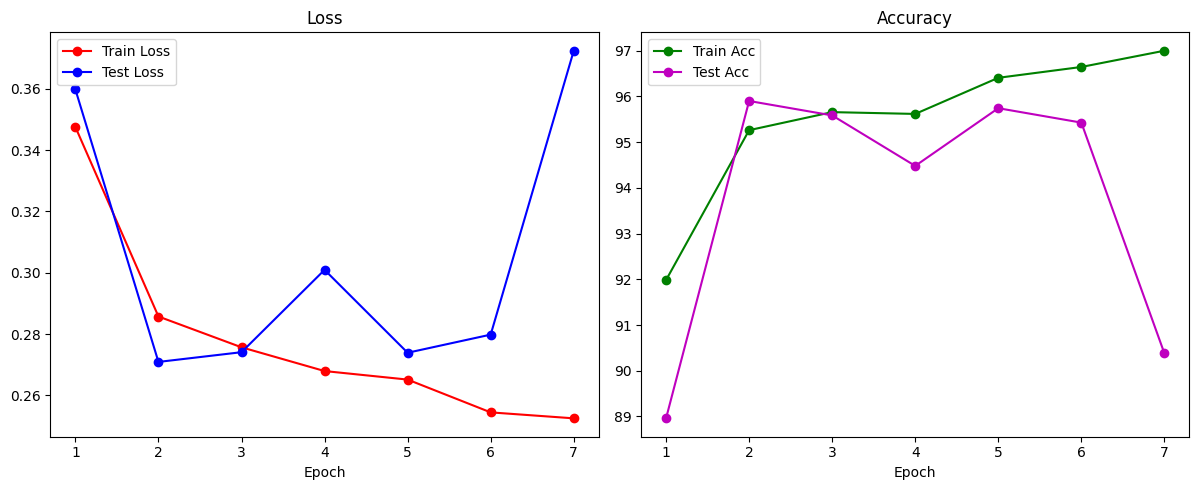


★ Quantum Hybrid (32+4) — 3W+7E — Best Test Acc: 95.90%


In [ ]:
# 11. Train Quantum Hybrid ResNet (32+4 ARCHITECTURE) — 3 Warmup + 7 Full
# =======================================================================
print("\n" + "="*60)
print("  CONFIG: 32+4 Hybrid Quantum — 3 Warmup + 7 Full Epochs")
print("="*60)
quantum_path = "/content/drive/MyDrive/best_quantum_32plus4_3w7e.pth"
q_model = QuantumResNet(num_classes=2, num_qubits=4, q_reps=2, proj_dim=4).to(device)
q_hist, q_acc = train_model(q_model, train_loader, test_loader, device, epochs=7, warmup_epochs=3, save_path=quantum_path)
plot_training(q_hist)
print(f"\n Quantum Hybrid (32+4) — 3W+7E — Best Test Acc: {q_acc:.2f}%")



--- Generating Metrics for Hybrid Quantum (32+4) — 3W+7E ---


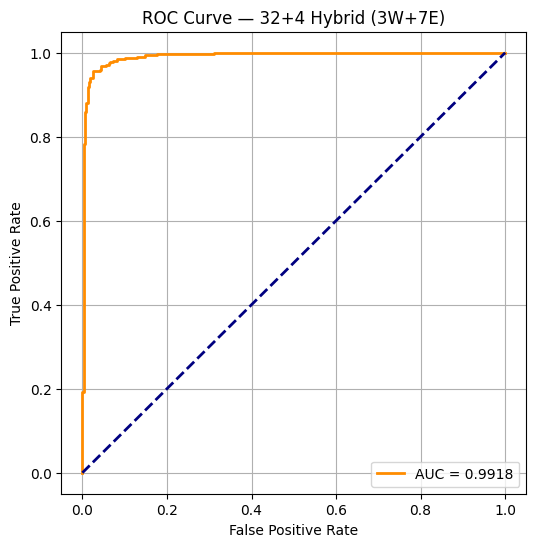

ROC AUC: 0.9918399028749415


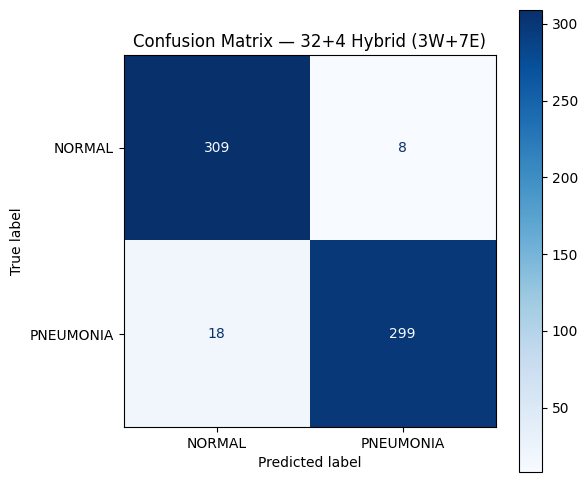


  CLASSIFICATION REPORT — 32+4 Hybrid (3W+7E)
              precision    recall  f1-score   support

      NORMAL     0.9450    0.9748    0.9596       317
   PNEUMONIA     0.9739    0.9432    0.9583       317

    accuracy                         0.9590       634
   macro avg     0.9594    0.9590    0.9590       634
weighted avg     0.9594    0.9590    0.9590       634

  Sensitivity (Recall):  0.9432
  Specificity:           0.9748
  Precision:             0.9739
  F1-Score:              0.9583
  Accuracy:              0.9590
  TP=299  TN=309  FP=8  FN=18

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  EXPERIMENT COMPLETE: 32+4 Hybrid Quantum — 3 Warmup + 7 Full
  Best Test Accuracy: 95.90%
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


In [ ]:
# 12. Metrics & Graphs (ROC Curve & Confusion Matrix)
# =======================================================================
def plot_roc_curve(model, dataloader, device):
    model.eval()
    y_true, y_score = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            y_score.extend(probs)
            y_true.extend(labels.numpy())

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — 32+4 Hybrid (3W+7E)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    print("ROC AUC:", roc_auc)

def plot_confusion_matrix(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA"])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    plt.title("Confusion Matrix — 32+4 Hybrid (3W+7E)")
    plt.show()

def print_classification_report(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    print("\n" + "="*60)
    print("  CLASSIFICATION REPORT — 32+4 Hybrid (3W+7E)")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], digits=4))

    # Compute specificity manually
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)  # Recall for Pneumonia
    specificity = tn / (tn + fp)  # How well it identifies Normal
    precision = tp / (tp + fp)
    f1 = 2 * precision * sensitivity / (precision + sensitivity)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    print(f"  Sensitivity (Recall):  {sensitivity:.4f}")
    print(f"  Specificity:           {specificity:.4f}")
    print(f"  Precision:             {precision:.4f}")
    print(f"  F1-Score:              {f1:.4f}")
    print(f"  Accuracy:              {accuracy:.4f}")
    print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    print("="*60)

print("\n--- Generating Metrics for Hybrid Quantum (32+4) — 3W+7E ---")
q_model.load_state_dict(torch.load(quantum_path))
plot_roc_curve(q_model, test_loader, device)
plot_confusion_matrix(q_model, test_loader, device)
print_classification_report(q_model, test_loader, device)

# =======================================================================
# FINAL SUMMARY
# =======================================================================
print("\n" + ""*60)
print(f"  EXPERIMENT COMPLETE: 32+4 Hybrid Quantum — 3 Warmup + 7 Full")
print(f"  Best Test Accuracy: {q_acc:.2f}%")
print(""*60)